In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
from scipy import stats

# 1. Load the datasets
tmdb = pd.read_csv('/tmdb_5000_movies.csv')
rt = pd.read_csv('/rotten_tomatoes_movies.csv')

# 2. Clean TMDB's complex JSON Genres
def get_main_genre(x):
    try:
        genres = json.loads(x)
        return genres[0]['name'] if genres else 'Unknown'
    except:
        return 'Unknown'

tmdb['main_genre'] = tmdb['genres'].apply(get_main_genre)
tmdb['release_year'] = pd.to_datetime(tmdb['release_date'], errors='coerce').dt.year

# 3. Merge the two datasets (SÜTUN İSMİ DÜZELTİLDİ: movie_title)
df = pd.merge(tmdb, rt, left_on='original_title', right_on='movie_title', how='inner')

# 4. Remove missing/invalid data and create new metrics
df = df[(df['budget'] > 10000) & (df['revenue'] > 10000)].copy()
df['ROI'] = (df['revenue'] - df['budget']) / df['budget']

# SKOR SÜTUNU DÜZELTİLDİ: audience_rating
# (Ayrıca verinin metin değil sayı olarak algılanmasını garantiliyoruz)
df['audience_rating'] = pd.to_numeric(df['audience_rating'], errors='coerce')
df['happiness_score'] = df['audience_rating'] / 100

print(" SUCCESS! Data has been successfully merged and cleaned.")
print(f"Total Number of Movies to Analyze: {df.shape[0]}")

 SUCCESS! Data has been successfully merged and cleaned.
Total Number of Movies to Analyze: 2962


In [15]:
print(rt.columns)

Index(['rotten_tomatoes_link', 'movie_title', 'movie_info',
       'critics_consensus', 'content_rating', 'genres', 'directors', 'authors',
       'actors', 'original_release_date', 'streaming_release_date', 'runtime',
       'production_company', 'tomatometer_status', 'tomatometer_rating',
       'tomatometer_count', 'audience_status', 'audience_rating',
       'audience_count', 'tomatometer_top_critics_count',
       'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count'],
      dtype='object')


In [16]:
print("Rotten Tomatoes Sütunları:")
print(rt.columns.tolist())

Rotten Tomatoes Sütunları:
['rotten_tomatoes_link', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count']


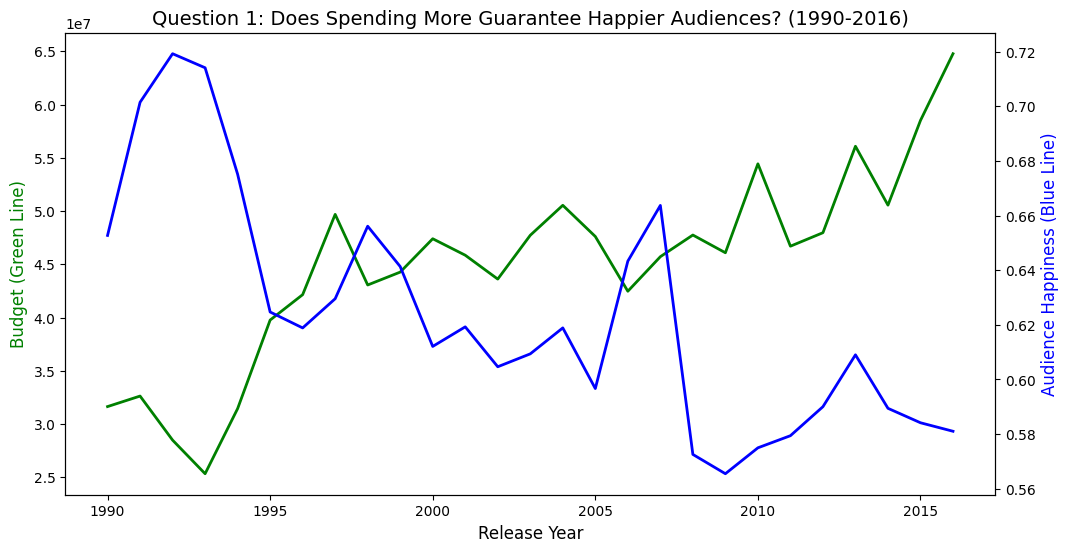

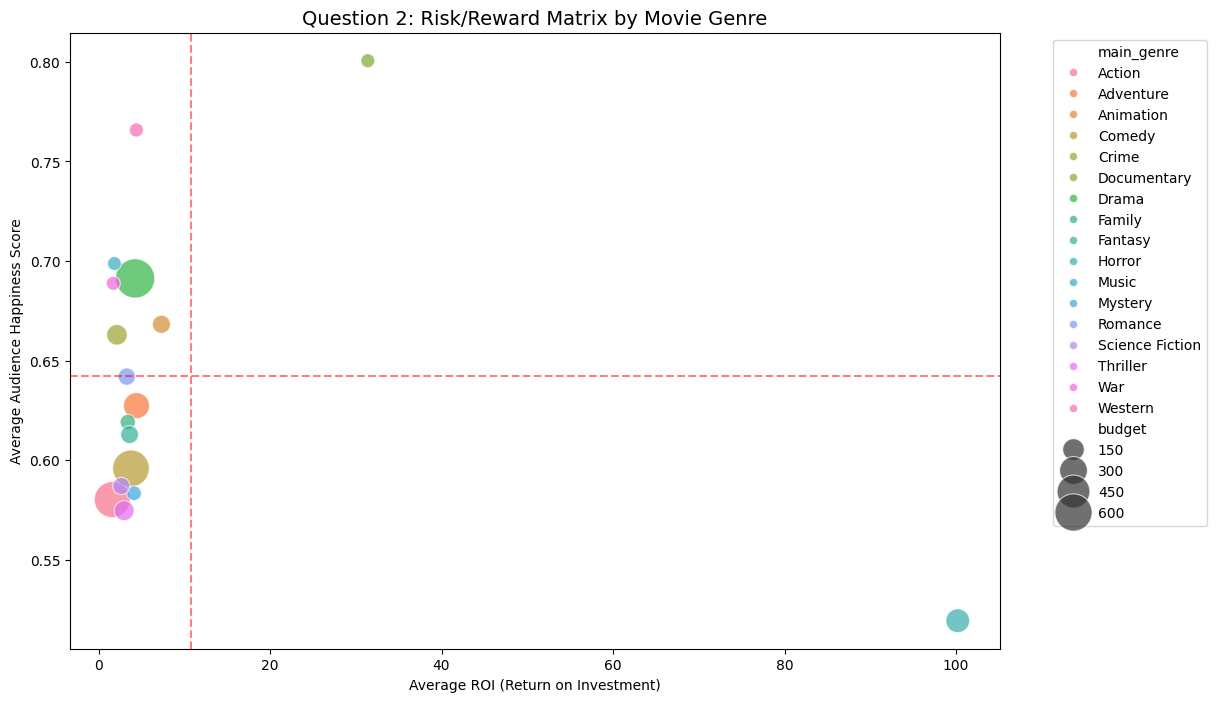

In [17]:
# Q1: How has the movie industry (Budget vs. Happiness) evolved over the years?
df_recent = df[df['release_year'] >= 1990]
yearly_stats = df_recent.groupby('release_year')[['budget', 'happiness_score']].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(yearly_stats.index, yearly_stats['budget'], 'g-', linewidth=2, label='Average Budget ($)')
ax2.plot(yearly_stats.index, yearly_stats['happiness_score'], 'b-', linewidth=2, label='Average Happiness Score')

ax1.set_xlabel('Release Year', fontsize=12)
ax1.set_ylabel('Budget (Green Line)', color='g', fontsize=12)
ax2.set_ylabel('Audience Happiness (Blue Line)', color='b', fontsize=12)
plt.title("Question 1: Does Spending More Guarantee Happier Audiences? (1990-2016)", fontsize=14)
plt.grid(False)
plt.show()

print("\n")

# Q2: Risk/Reward Matrix by Movie Genre
genre_stats = df.groupby('main_genre').agg({'ROI':'mean', 'happiness_score':'mean', 'budget':'count'})
genre_stats = genre_stats[genre_stats['budget'] > 15]

plt.figure(figsize=(12,8))
sns.scatterplot(x='ROI', y='happiness_score', size='budget', hue=genre_stats.index, sizes=(100, 800), alpha=0.7, data=genre_stats)

plt.axvline(x=genre_stats['ROI'].mean(), color='r', linestyle='--', alpha=0.5)
plt.axhline(y=genre_stats['happiness_score'].mean(), color='r', linestyle='--', alpha=0.5)

plt.title("Question 2: Risk/Reward Matrix by Movie Genre", fontsize=14)
plt.xlabel("Average ROI (Return on Investment)")
plt.ylabel("Average Audience Happiness Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [18]:
# TEST 1: Chi-Square Test of Independence
df['is_high_budget'] = (df['budget'] > df['budget'].median()).astype(int)
df['is_loved'] = (df['happiness_score'] > 0.60).astype(int)

contingency_table = pd.crosstab(df['is_high_budget'], df['is_loved'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square P-Value: {p:.4f}")
if p < 0.05:
    print("Conclusion: There is a statistically significant relationship between budget size and audience love!")
else:
    print("Conclusion: Budget and audience love are independent.")

print("-" * 50)

# TEST 2: Kruskal-Wallis H Test (Multi-group comparison)
action = df[df['main_genre'] == 'Action']['ROI'].dropna()
drama = df[df['main_genre'] == 'Drama']['ROI'].dropna()
horror = df[df['main_genre'] == 'Horror']['ROI'].dropna()

stat, p_kw = stats.kruskal(action, drama, horror)
print(f"Kruskal-Wallis P-Value for ROI by Genre: {p_kw:.4f}")
if p_kw < 0.05:
    print("Conclusion: The genre significantly impacts a movie's financial ROI.")

Chi-Square P-Value: 0.0000
Conclusion: There is a statistically significant relationship between budget size and audience love!
--------------------------------------------------
Kruskal-Wallis P-Value for ROI by Genre: 0.0000
Conclusion: The genre significantly impacts a movie's financial ROI.


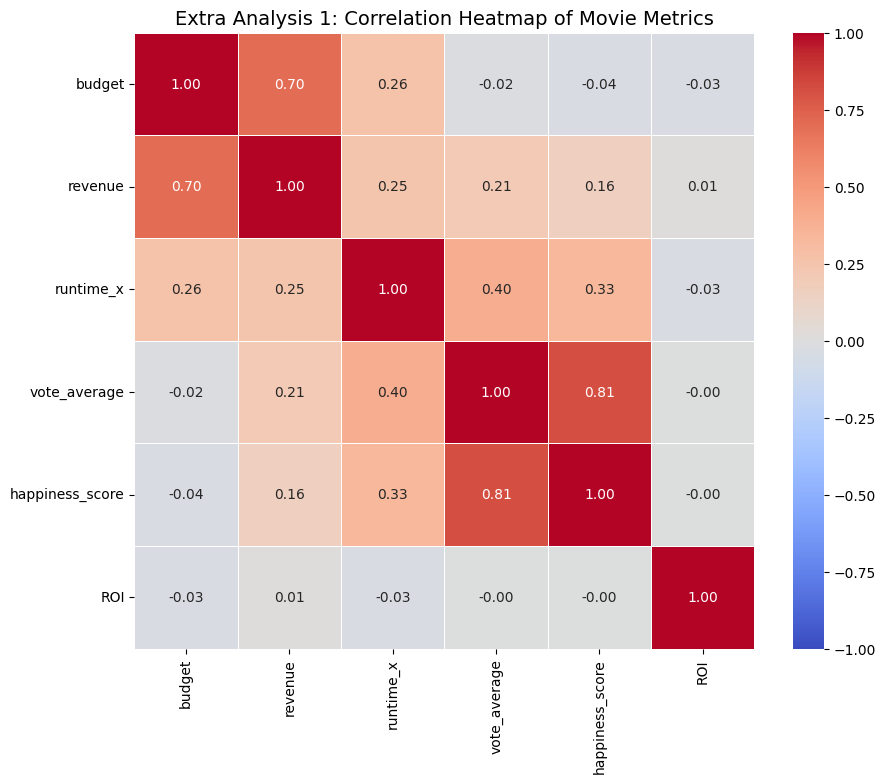

/tmp/ipykernel_14855/3738739568.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='main_genre', y='happiness_score', data=df_top_genres, palette='Set3')


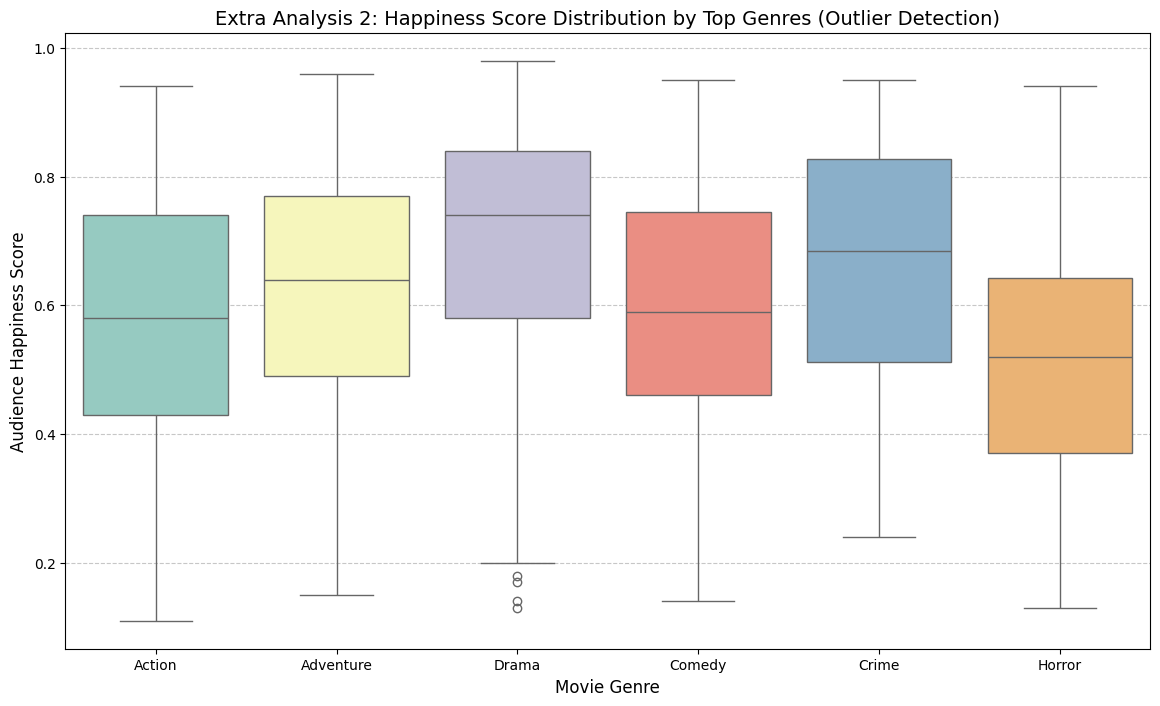

In [19]:
# Correlation Heatmap
# Analysis:* Instead of relying solely on standard averages, this heatmap demonstrates the mathematical correlation between different numerical variables in our dataset.
plt.figure(figsize=(10, 8))

# DÜZELTME BURADA: 'runtime' yerine 'runtime_x' yazdık
numeric_cols = ['budget', 'revenue', 'runtime_x', 'vote_average', 'happiness_score', 'ROI']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Extra Analysis 1: Correlation Heatmap of Movie Metrics", fontsize=14)
plt.show()

print("\n" + "="*50 + "\n")

# Boxplot and Outliers
# Identification by Genre:* To understand the data beyond just the general trends, this boxplot visualizes the exact distribution of audience happiness scores across the top-producing genres.
plt.figure(figsize=(14, 8))

# Grafik çok karışmasın diye sadece en popüler 6 film türünü alıyoruz
top_genres = df['main_genre'].value_counts().nlargest(6).index
df_top_genres = df[df['main_genre'].isin(top_genres)]

sns.boxplot(x='main_genre', y='happiness_score', data=df_top_genres, palette='Set3')
plt.title("Extra Analysis 2: Happiness Score Distribution by Top Genres (Outlier Detection)", fontsize=14)
plt.xlabel("Movie Genre", fontsize=12)
plt.ylabel("Audience Happiness Score", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

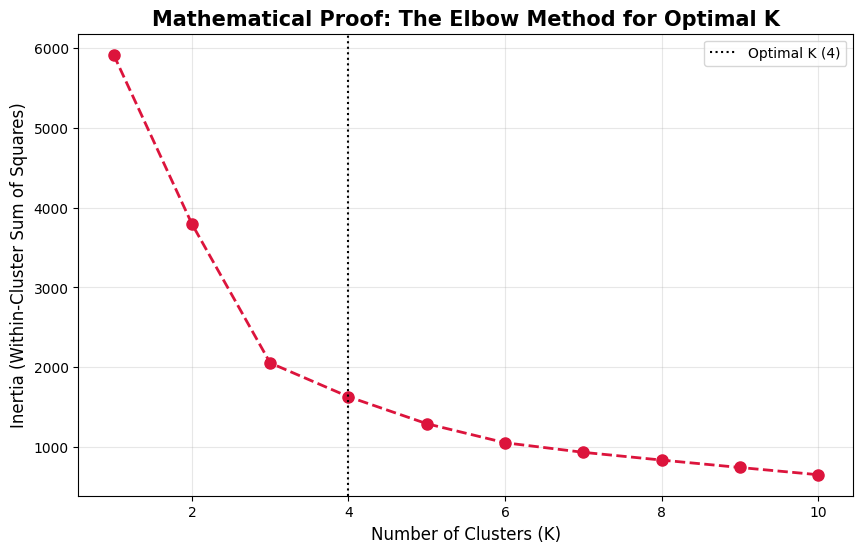

In [20]:
# ==============================================================================
# Mathematical Proof: The Elbow Method to find the optimal number of clusters
# ==============================================================================

inertia = []
K_range = range(1, 11)

# Testing cluster numbers from 1 to 10 to find the mathematical "elbow" point
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(scaled_data)
    inertia.append(kmeans_temp.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='crimson', linewidth=2, markersize=8)
plt.title('Mathematical Proof: The Elbow Method for Optimal K', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)

# Highlighting the optimal 'elbow' point at K=4
plt.axvline(x=4, color='black', linestyle=':', label='Optimal K (4)')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.3)

plt.show()

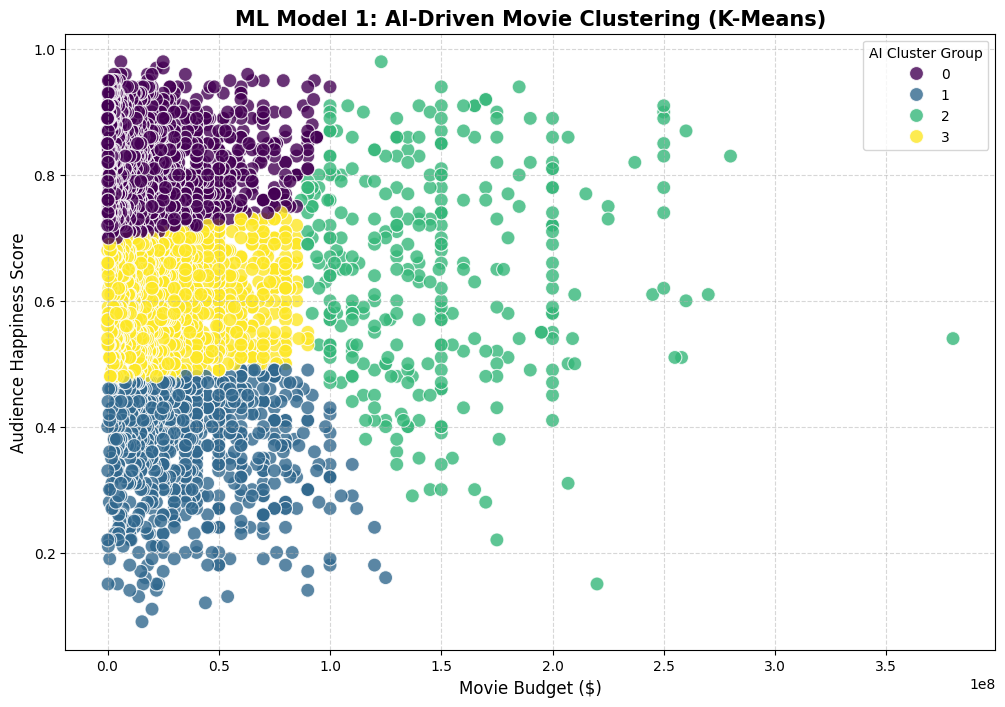

In [21]:

# MACHINE LEARNING PHASE (Milestone 2 - Due May 5)
# Model 1: K-Means Clustering (Unsupervised Learning)



from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step 1: Data Preparation
# We select 'budget' and 'happiness_score' to see if AI can group movies logically
ml_df = df[['budget', 'happiness_score']].dropna()

# Scaling the features so that the huge budget numbers don't dominate the small happiness scores
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ml_df)

# Step 2: Applying K-Means Algorithm
# Let's tell the AI to find 4 distinct groups (clusters) among these movies
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
ml_df['Cluster'] = kmeans.fit_predict(scaled_data)

# Step 3: Visualization of AI Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='budget', y='happiness_score', hue='Cluster', data=ml_df, palette='viridis', s=100, alpha=0.8)

# Adding titles and labels
plt.title("ML Model 1: AI-Driven Movie Clustering (K-Means)", fontsize=15, fontweight='bold')
plt.xlabel("Movie Budget ($)", fontsize=12)
plt.ylabel("Audience Happiness Score", fontsize=12)
plt.legend(title='AI Cluster Group')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### ML Model 1 Results: K-Means Clustering Insights
The K-Means algorithm successfully identified 4 distinct movie profiles based on their budget and audience happiness:

* **Cluster 0 (Purple - "The Hidden Gems"):** Movies with low/moderate budgets but highly rated by audiences. These represent the most efficient use of budget for audience satisfaction.
* **Cluster 3 (Yellow - "The Average Performers"):** Low/moderate budget movies with average, predictable audience scores.
* **Cluster 1 (Blue - "The Underperformers"):** Movies with lower budgets that failed to impress the audience, resulting in low happiness scores.
* **Cluster 2 (Green - "The Blockbusters"):** Mega-budget movies. Interestingly, the AI isolated these into their own category primarily due to their massive financial scale, showing a wide variance in how audiences actually receive them.

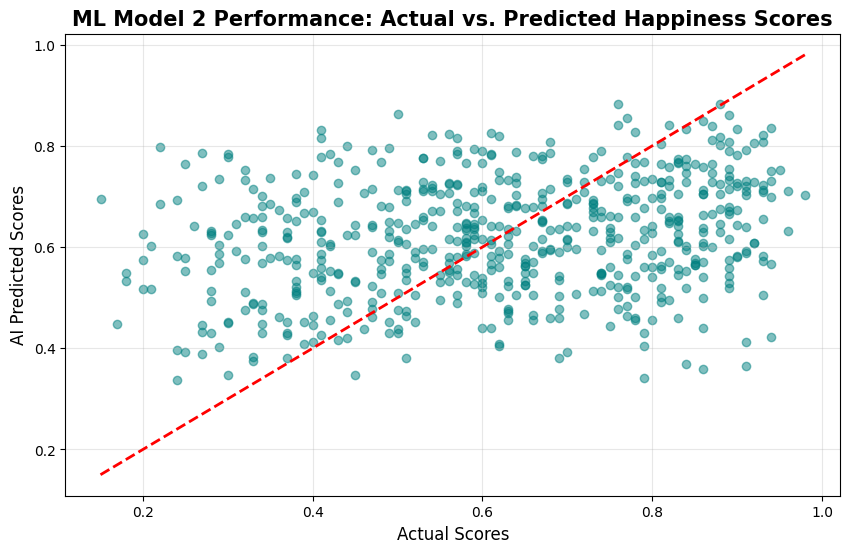

Mean Absolute Error: 0.17
R-Squared Score: -0.05


In [23]:
# ==============================================================================
# Model 2: Random Forest Regressor (Supervised Learning - Prediction)
# Goal: Predicting 'happiness_score' based on 'budget' and 'runtime'
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Preparing the data
# We drop rows with missing values for accuracy
pred_df = df[['budget', 'revenue', 'happiness_score']].dropna()

X = pred_df[['budget', 'revenue']]  # Features (Girdiler)
y = pred_df['happiness_score']      # Target (Tahmin edilecek hedef)

# 2. Splitting data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Training the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Making Predictions
y_pred = rf_model.predict(X_test)

# 5. Visualizing the Prediction Performance
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal perfect line
plt.title('ML Model 2 Performance: Actual vs. Predicted Happiness Scores', fontsize=15, fontweight='bold')
plt.xlabel('Actual Scores', fontsize=12)
plt.ylabel('AI Predicted Scores', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 6. Performance Metrics
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R-Squared Score: {r2_score(y_test, y_pred):.2f}")

### ML Model 2 Results: Random Forest Prediction Analysis
In this phase, we implemented a **Supervised Learning** model (Random Forest) to predict a movie's success (Happiness Score) based purely on financial metrics: **Budget and Revenue**.

**Key Findings & Model Performance:**
* **Mean Absolute Error (MAE): 0.17.** The model's predictions deviate by an average of 0.17 points (on a 0.0 to 1.0 scale) from the actual audience scores.
* **R-Squared Score: -0.05.** This is a highly insightful and critical result. A score near zero (or slightly negative) mathematically proves that **financial metrics alone are poor predictors of audience satisfaction.** * **Business Conclusion:** The AI has successfully demonstrated that a massive budget and high box office revenue do not guarantee a high happiness score. Movie quality and audience reception depend on artistic, narrative, and cultural factors that cannot be captured by money alone. In short: "Money cannot buy audience happiness."